### Importación de librerías

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as f
from pyspark.sql.types import NumericType, StringType
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import os

### Conexión

In [3]:
os.environ["HADOOP_HOME"] = r"C:\hadoop"
os.environ["PATH"] += os.pathsep + r"C:\hadoop\bin"

In [4]:
spark = (SparkSession.builder.appName("Proyecto_PySpark").master("local[*]").getOrCreate())

/usr/local/lib/python3.11/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/28 02:44:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### Importación de datos.

In [5]:
df_2025 = spark.read.parquet("df_2025.parquet")
df_2026 = spark.read.parquet("df_2026.parquet")

### Variables utilizadas

In [6]:
variables_numericas = ["edad", "antiguedad_total", "horas_semanales"]
variables_categoricas = ["nivel_educativo", "categoria_ocupacional", "dominio"]
variable_objetivo = "salario_mensual"

### Separación validación y entrenamiento

In [7]:
train_df, valid_df = df_2025.randomSplit(weights=[0.75, 0.25], seed=0)

## Inciso 5

#### Variables categóricas

In [8]:
indexers = [StringIndexer(inputCol=columna,
                          outputCol=f"{columna}_index",
                          handleInvalid="keep")
            for columna in variables_categoricas]

In [9]:
encoder = OneHotEncoder(inputCols=[f"{columna}_index" for columna in variables_categoricas],
                        outputCols=[f"{columna}_ohe" for columna in variables_categoricas],
                        dropLast=True)

#### Vector Assembler

In [10]:
assembler = VectorAssembler(inputCols=variables_numericas + [f"{columna}_ohe" for columna in variables_categoricas],
                            outputCol="features_sin_escalar")

#### Variables numéricas

In [11]:
scaler = StandardScaler(inputCol="features_sin_escalar", outputCol="features",
                        withMean=True, withStd=True)

#### Evaluadores

In [12]:
evaluator_mae = RegressionEvaluator(labelCol="salario_mensual", predictionCol="prediction", metricName="mae")
evaluator_rmse = RegressionEvaluator(labelCol="salario_mensual", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="salario_mensual", predictionCol="prediction", metricName="r2")

### Configuración 1

#### Regresión lineal

In [13]:
lr1 = LinearRegression(featuresCol="features", labelCol=variable_objetivo,
                       predictionCol="prediction", regParam=0.0,
                       elasticNetParam=0.0, maxIter=100)

#### Pipeline

In [14]:
pipeline_lr1 = Pipeline(stages=[*indexers, encoder, assembler, scaler, lr1])

#### Entrenamiento del modelo

In [15]:
modelo_lr1 = pipeline_lr1.fit(train_df)

26/09/28 02:44:43 WARN Instrumentation: [fb2f7415] regParam is zero, which might cause numerical instability and overfitting.
26/09/28 02:44:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/28 02:44:44 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/09/28 02:44:45 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/09/28 02:44:45 WARN Instrumentation: [fb2f7415] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
                                                                                

#### Predicción de validación

In [16]:
pred_1 = modelo_lr1.transform(valid_df)

#### Métricas

In [17]:
mae_1 = evaluator_mae.evaluate(pred_1)
rmse_1 = evaluator_rmse.evaluate(pred_1)
r2_1 = evaluator_r2.evaluate(pred_1)

print("Configuración 1")
print("MAE:", mae_1)
print("RMSE:", rmse_1)
print("R²:", r2_1)

[Stage 22:==>                                                     (1 + 18) / 19]

Configuración 1
MAE: 1241.7804231962104
RMSE: 2314.756008932371
R²: 0.39621460737307546


### Configuración 2

#### Regresión lineal

In [18]:
lr2 = LinearRegression(featuresCol="features", labelCol="salario_mensual",
                        predictionCol="prediction", regParam=1,
                        elasticNetParam=0.4, maxIter=100)

#### Pipeline

In [19]:
pipeline_lr2 = Pipeline(stages=[*indexers, encoder, assembler, scaler, lr2])

#### Entrenamiento del modelo

In [20]:
modelo_lr2 = pipeline_lr2.fit(train_df)

#### Predicción de validación

In [21]:
pred_2 = modelo_lr2.transform(valid_df)

#### Métricas

In [22]:
mae_2 = evaluator_mae.evaluate(pred_2)
rmse_2 = evaluator_rmse.evaluate(pred_2)
r2_2 = evaluator_r2.evaluate(pred_2)

print("Configuración 2")
print("MAE:", mae_2)
print("RMSE:", rmse_2)
print("R²:", r2_2)

[Stage 44:==>                                                     (1 + 18) / 19]

Configuración 2
MAE: 1241.565804425256
RMSE: 2314.776256310985
R²: 0.39620404459681235


## Inciso 6

### Configuración 1

#### Random Forest

In [23]:
rf_1 = RandomForestRegressor(featuresCol="features", labelCol="salario_mensual",
                             predictionCol="prediction", numTrees=75,
                             maxDepth=5, seed=0)

#### Pipeline

In [24]:
pipeline_rf_1 = Pipeline(stages=[*indexers, encoder, assembler, scaler, rf_1])

#### Entrenamiento del modelo

In [25]:
modelo_rf_1 = pipeline_rf_1.fit(train_df)

#### Predicción de validación

In [26]:
pred_rf_1 = modelo_rf_1.transform(valid_df)

#### Métricas

In [27]:
mae_rf_1 = evaluator_mae.evaluate(pred_rf_1)
rmse_rf_1 = evaluator_rmse.evaluate(pred_rf_1)
r2_rf_1 = evaluator_r2.evaluate(pred_rf_1)

print("Configuración 1")
print("MAE:", mae_rf_1)
print("RMSE:", rmse_rf_1)
print("R²:", r2_rf_1)

[Stage 76:==>                                                     (1 + 18) / 19]

Configuración 1
MAE: 1184.9332028611188
RMSE: 2267.394016710696
R²: 0.4206698191573627


### Configuración 2

#### Random Forest

In [28]:
rf_2 = RandomForestRegressor(featuresCol="features", labelCol="salario_mensual",
                             predictionCol="prediction", numTrees=100,
                             maxDepth=7, seed=0)

#### Pipeline

In [29]:
pipeline_rf_2 = Pipeline(stages=[*indexers, encoder, assembler, scaler, rf_2])

#### Entrenamiento del modelo

In [30]:
modelo_rf_2 = pipeline_rf_2.fit(train_df)

26/09/28 02:45:27 WARN DAGScheduler: Broadcasting large task binary with size 1041.3 KiB
26/09/28 02:45:27 WARN DAGScheduler: Broadcasting large task binary with size 1830.9 KiB
                                                                                

#### Predicción de validación

In [31]:
pred_rf_2 = modelo_rf_2.transform(valid_df)

#### Métricas

In [32]:
mae_rf_2 = evaluator_mae.evaluate(pred_rf_2)
rmse_rf_2 = evaluator_rmse.evaluate(pred_rf_2)
r2_rf_2 = evaluator_r2.evaluate(pred_rf_2)

print("Configuración 2")
print("MAE:", mae_rf_2)
print("RMSE:", rmse_rf_2)
print("R²:", r2_rf_2)

[Stage 112:==>                                                    (1 + 18) / 19]

Configuración 2
MAE: 1129.9293214775503
RMSE: 2126.583713484995
R²: 0.49039095389302356


## Inciso 7

In [35]:
#elección del mejor modelo: REGRESION LINEAL
print("Configuración Diferencia REGRESION LINEAL (m1-m2)")
print("MAE:", mae_1-mae_2)
print("RMSE:", rmse_1-rmse_2)
print("R²:", r2_1-r2_2)

Configuración Diferencia REGRESION LINEAL (m1-m2)
MAE: 0.2146187709545302
RMSE: -0.020247378613930778
R²: 1.0562776263101092e-05


In [36]:
#elección del mejor modelo: RANDOM FOREST
print("Configuración Diferencia RANDOM FOREST (m1-m2)")
print("MAE:", mae_rf_1-mae_rf_2)
print("RMSE:", rmse_rf_1-rmse_rf_2)
print("R²:", r2_rf_1-r2_rf_2)

Configuración Diferencia RANDOM FOREST (m1-m2)
MAE: 55.00388138356857
RMSE: 140.81030322570132
R²: -0.06972113473566088


Se elige para el modelo de REGRESIÓN LINEAL el **Modelo 1**, dado que aunque la diferencia entre ambos modelos es considerablemente pequeña -en particular para la métrica $R^2$-, este modelo presenta una ligera ventaja, de acuerdo con las métricas estudiadas.

En cuanto al modelo de RANDOM FOREST, se observa que el **Modelo 2** presenta mejores métricas que el primero, lo que se hace más evidente en las diferencias de las métricas mostradas antes.


Se realizan nuevas predicciones sobre el conjunto de 2026

In [37]:
#MODELO 1 REGRESION LINEAL
pred_2026_lr1 = modelo_lr1.transform(df_2026)

#MODELO 2 RANDOM FOREST
pred_2026_rf2 = modelo_rf_2.transform(df_2026)

Se procede a la comparación de métricas:

In [38]:
def evaluar_predicciones(predicciones):

    mae = evaluator_mae.evaluate(predicciones)
    rmse = evaluator_rmse.evaluate(predicciones)
    r2 = evaluator_r2.evaluate(predicciones)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [47]:
resultados_2026 = {
    "Regresión lineal 1":evaluar_predicciones(pred_2026_lr1),

    "Random Forest 2":evaluar_predicciones(pred_2026_rf2)
}

resultados_2025 = {
    "Regresión lineal 1": evaluar_predicciones(pred_1),
    
    "Random Forest 2": evaluar_predicciones(pred_rf_2)
}

for modelo, metricas in resultados_2026.items():

    print(f"\n{modelo}")

    for metrica, valor in metricas.items():
        print(f"{metrica}: {valor:.4f}")

[Stage 184:==>                                                    (1 + 18) / 19]


Regresión lineal 1
MAE: 1243.7744
RMSE: 2265.7795
R2: 0.4042

Random Forest 2
MAE: 1118.9531
RMSE: 2062.4566
R2: 0.5063


Se procede a probar si estos resultados son mejores a los anteriores del 2025, lo que en consecuencia puede evidenciar qué tan bien generaliza el modelo.

In [51]:
import pandas as pd #ESTO SE HACE SOLAMENTE PARA QUE LA TABLA SE VEA BIEN
filas = []

for modelo, metricas_2026 in resultados_2026.items():

    metricas_2025 = resultados_2025[modelo]

    for metrica, valor_2026 in metricas_2026.items():

        valor_2025 = metricas_2025[metrica]

        filas.append({
            "Modelo": modelo,
            "Métrica": metrica,
            "2025": valor_2025,
            "2026": valor_2026,
            "Diferencia": valor_2026 - valor_2025
        })

comparacion = pd.DataFrame(filas)

display(comparacion.round(4))

,Modelo,Métrica,2025,2026,Diferencia
0,Regresión lineal 1,MAE,1241.7804,1243.7744,1.9939
1,Regresión lineal 1,RMSE,2314.7560,2265.7795,-48.9765
2,Regresión lineal 1,R2,0.3962,0.4042,0.0080
3,Random Forest 2,MAE,1129.9293,1118.9531,-10.9762
4,Random Forest 2,RMSE,2126.5837,2062.4566,-64.1272
5,Random Forest 2,R2,0.4904,0.5063,0.0160


**Regresión lineal 1:**

Se observa que en general no existe una gran diferencia entre estos modelos, a excepción de lo que muestra la métrica RMSE, en el que se nos dice que el modelo predecía mejor para 2025, lo que no es de extrañar dado que es para estos datos para los que fue entrenado. Aún así, puede considerarse que en general las predicciones para el 2026 son ligeramente menos acertadas que las de 2025, pero tan aceptables como estas.

**Random Forest 2:**

Se muestra en este caso que las métricas han mejorado en todos los casos respecto al 2025. No obstante, dada la naturaleza del Random Forest al sobreajuste, no puede asegurarse que el modelo sea el más apropiado. 

## Inciso 8

In [53]:
#Modelos para 2026 de los modelos faltantes
#MODELO 2 REGRESION LINEAL
pred_2026_lr2 = modelo_lr2.transform(df_2026)

#MODELO 1 RANDOM FOREST
pred_2026_rf1 = modelo_rf_1.transform(df_2026)

In [54]:
#Funciones para los cálculos de esta sección
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

def agregar_errores(predicciones):

    return (
        predicciones
        .withColumn(
            "residuo",
            F.col("salario_mensual")
            - F.col("prediction")
        )
        .withColumn(
            "error_absoluto",
            F.abs(
                F.col("salario_mensual")
                - F.col("prediction")
            )
        )
    )


def grafico_real_predicho(predicciones,nombre_modelo,n_muestra=5000,semilla=42):

    n = predicciones.count()

    if n > n_muestra:
        fraccion = min(
            1.0,
            n_muestra / n
        )

        datos = (
            predicciones
            .select(
                "salario_mensual",
                "prediction"
            )
            .sample(
                False,
                fraccion,
                seed=semilla
            )
            .limit(n_muestra)
            .toPandas()
        )

    else:
        datos = (
            predicciones
            .select(
                "salario_mensual",
                "prediction"
            )
            .toPandas()
        )

    minimo = min(
        datos["salario_mensual"].min(),
        datos["prediction"].min()
    )

    maximo = max(
        datos["salario_mensual"].max(),
        datos["prediction"].max()
    )

    plt.figure(figsize=(7, 7))

    plt.scatter(
        datos["salario_mensual"],
        datos["prediction"],
        alpha=0.3,
        s=15
    )

    # Línea ideal y = x
    plt.plot(
        [minimo, maximo],
        [minimo, maximo],
        linestyle="--",
        label="Predicción perfecta (y = x)"
    )

    plt.xlabel("Salario real")
    plt.ylabel("Salario predicho")

    plt.title(
        f"Salario real vs. predicho\n{nombre_modelo}"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

def grafico_residuos(predicciones,nombre_modelo,n_muestra=5000,semilla=42):

    datos_spark = agregar_errores(
        predicciones
    )

    n = datos_spark.count()

    if n > n_muestra:

        fraccion = min(
            1.0,
            n_muestra / n
        )

        datos = (
            datos_spark
            .select(
                "prediction",
                "residuo"
            )
            .sample(
                False,
                fraccion,
                seed=semilla
            )
            .limit(n_muestra)
            .toPandas()
        )

    else:

        datos = (
            datos_spark
            .select(
                "prediction",
                "residuo"
            )
            .toPandas()
        )

    plt.figure(figsize=(8, 5))

    plt.scatter(
        datos["prediction"],
        datos["residuo"],
        alpha=0.3,
        s=15
    )

    # Residuo ideal = 0
    plt.axhline(
        y=0,
        linestyle="--",
        label="Residuo = 0"
    )

    plt.xlabel("Salario predicho")
    plt.ylabel("Residuo (real - predicho)")

    plt.title(f"Residuos vs. salario predicho\n{nombre_modelo}")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

def errores_por_grupo(predicciones,columna_grupo):

    datos = agregar_errores(predicciones)

    tabla = (datos.groupBy(columna_grupo).agg(F.count("*").alias("n_observaciones"), F.avg("error_absoluto").alias("MAE"),F.avg("residuo").alias("error_medio")).orderBy(columna_grupo))

    return tabla



In [58]:
modelos_predicciones = {
    "Regresión Lineal 1": pred_2026_lr1,
    "Regresión Lineal 2": pred_2026_lr2,
    "Random Forest 1": pred_2026_rf1,
    "Random Forest 2": pred_2026_rf2
}


Regresión Lineal 1


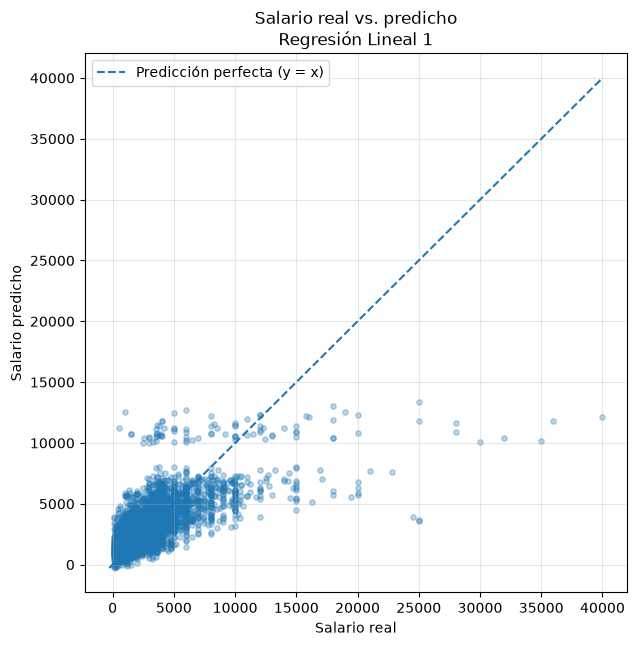

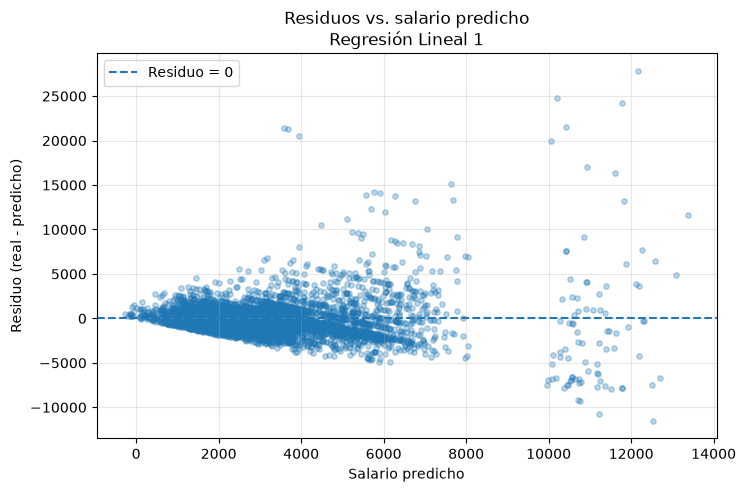


Errores por nivel educativo:
+---------------+---------------+-----------------+-------------------+
|nivel_educativo|n_observaciones|MAE              |error_medio        |
+---------------+---------------+-----------------+-------------------+
|0              |1050           |875.458444110727 |-10.746577396566884|
|1              |138            |736.9541911489965|-43.363594810202294|
|2              |4062           |856.9963091171891|-3.0744233819675846|
|3              |2079           |865.7695697105945|-1.5808262783571858|
|4              |4196           |1142.20676089073 |8.204171310096767  |
|5              |1674           |2555.308185325615|14.03922599969513  |
|6              |202            |5870.217046572891|105.77898299742648 |
|7              |18             |7341.872535868824|74.57011525301317  |
+---------------+---------------+-----------------+-------------------+


Errores por dominio:
+-------+---------------+------------------+-------------------+
|dominio|n_observa

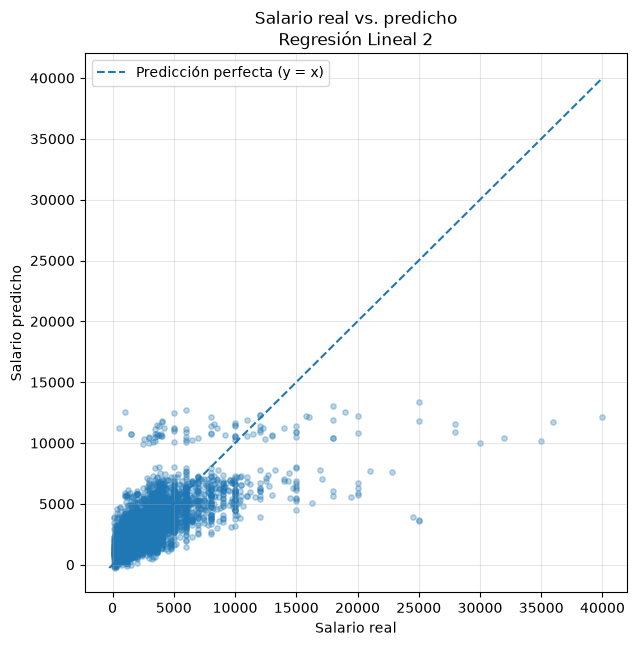

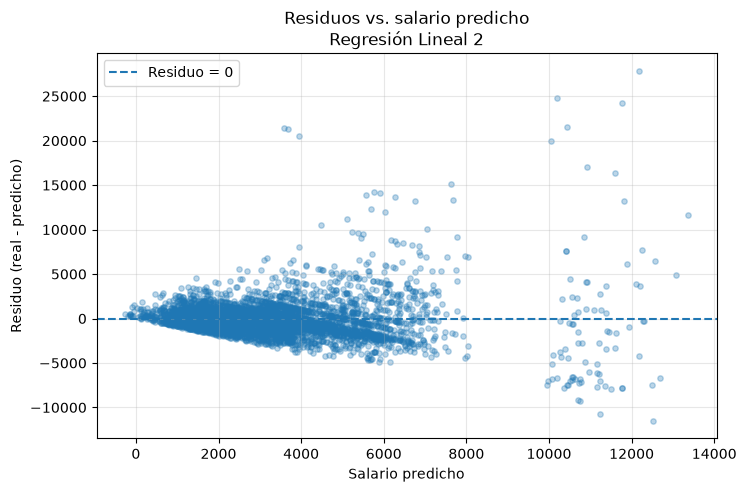


Errores por nivel educativo:
+---------------+---------------+------------------+-------------------+
|nivel_educativo|n_observaciones|MAE               |error_medio        |
+---------------+---------------+------------------+-------------------+
|0              |1050           |875.2597049756439 |-12.774778432639062|
|1              |138            |736.8013285862529 |-47.837372009090224|
|2              |4062           |856.824574640593  |-3.7823245435139663|
|3              |2079           |865.638379862689  |-2.842635435880106 |
|4              |4196           |1141.9863067749147|9.167047401482158  |
|5              |1674           |2554.969359585321 |15.79112135610313  |
|6              |202            |5869.032870111538 |110.91214136586935 |
|7              |18             |7339.177867871119 |86.52187241307972  |
+---------------+---------------+------------------+-------------------+


Errores por dominio:
+-------+---------------+------------------+-------------------+
|domin

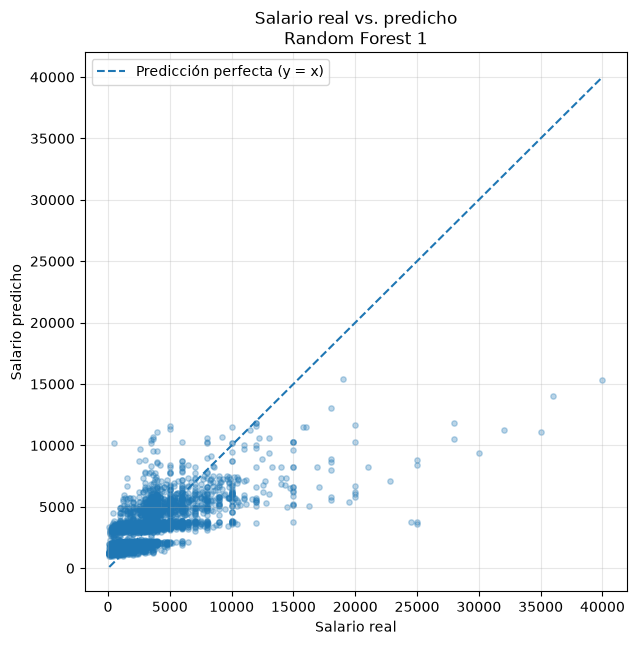

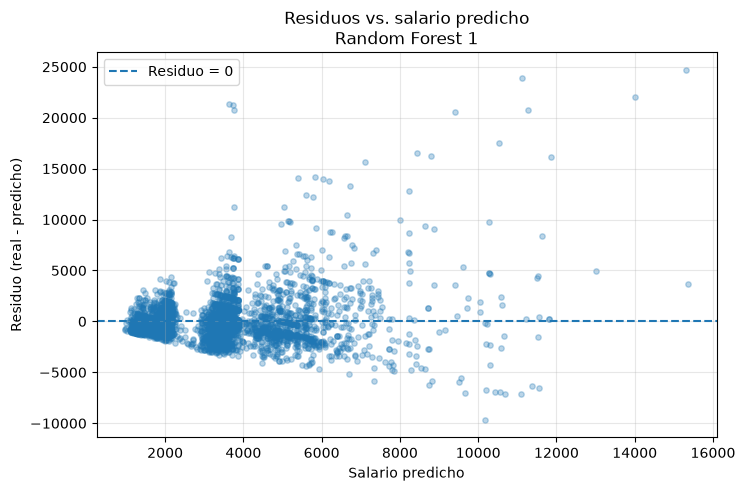


Errores por nivel educativo:
+---------------+---------------+------------------+-------------------+
|nivel_educativo|n_observaciones|MAE               |error_medio        |
+---------------+---------------+------------------+-------------------+
|0              |1050           |856.0058790517226 |-423.75287037591966|
|1              |138            |865.8434604774305 |-591.4271245569478 |
|2              |4062           |816.1010874709232 |-156.94540088106456|
|3              |2079           |861.7408247050214 |-235.1286983340038 |
|4              |4196           |1091.1145849817053|169.57163008829684 |
|5              |1674           |2375.2670595380164|353.24416063586875 |
|6              |202            |5151.912620292306 |1267.217253093379  |
|7              |18             |7044.484919255612 |6065.228546466436  |
+---------------+---------------+------------------+-------------------+


Errores por dominio:
+-------+---------------+------------------+-------------------+
|domin

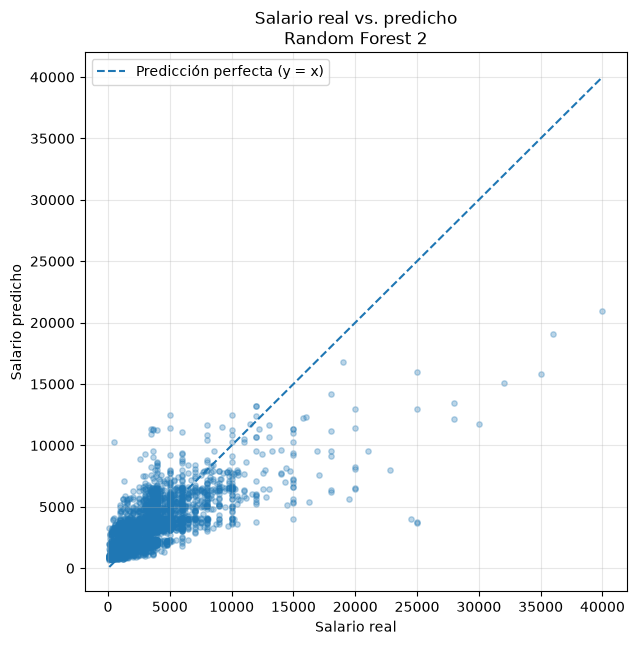

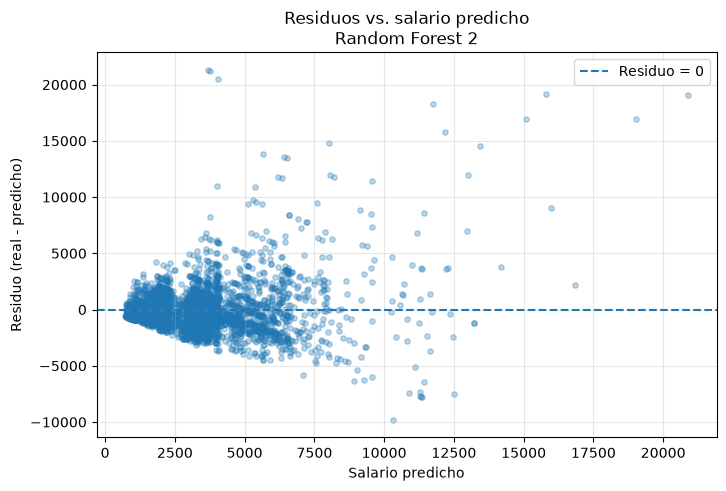


Errores por nivel educativo:
+---------------+---------------+------------------+-------------------+
|nivel_educativo|n_observaciones|MAE               |error_medio        |
+---------------+---------------+------------------+-------------------+
|0              |1050           |755.8832889841281 |-265.1952212140806 |
|1              |138            |736.9895854983348 |-449.35282432422173|
|2              |4062           |766.0812939974256 |-76.5668954701324  |
|3              |2079           |796.3052853091158 |-101.0886989950604 |
|4              |4196           |1066.4641945967546|88.81976722030016  |
|5              |1674           |2296.4054372561122|194.73982613926916 |
|6              |202            |4603.043364872434 |631.9603210768403  |
|7              |18             |5757.083878413004 |3726.861692281678  |
+---------------+---------------+------------------+-------------------+


Errores por dominio:
+-------+---------------+------------------+-------------------+
|domin

In [64]:
for nombre, predicciones in modelos_predicciones.items():

    print("\n" + "=" * 70)
    print(nombre)
    print("=" * 70)

# GRAFICO REAL VS. PREDICHO

    grafico_real_predicho(predicciones, nombre)

# GRAFICO DE RESIDUOS

    grafico_residuos(predicciones,nombre)

# NIVEL EDUCATIVO

    print("\nErrores por nivel educativo:")

    tabla_educacion = errores_por_grupo(predicciones,"nivel_educativo")

    tabla_educacion.show(truncate=False)

#DOMINIO

    print("\nErrores por dominio:")

    tabla_dominio = errores_por_grupo(predicciones,"dominio")

    tabla_dominio.show(truncate=False)

In [69]:
#TABLA UNIFICADA:
from functools import reduce
tablas_educacion = []

for nombre, predicciones in modelos_predicciones.items():

    tabla = (errores_por_grupo(predicciones,"nivel_educativo").withColumn("modelo",F.lit(nombre)))

    tablas_educacion.append(tabla)

tabla_educacion_completa = reduce(
    lambda a, b: a.unionByName(b),
    tablas_educacion
)

tabla_educacion_completa.select(
    "modelo",
    "nivel_educativo",
    "n_observaciones",
    "MAE",
    "error_medio"
).show(
    truncate=False
)

+------------------+---------------+---------------+------------------+-------------------+
|modelo            |nivel_educativo|n_observaciones|MAE               |error_medio        |
+------------------+---------------+---------------+------------------+-------------------+
|Regresión Lineal 1|0              |1050           |875.458444110727  |-10.746577396566884|
|Regresión Lineal 1|1              |138            |736.9541911489965 |-43.363594810202294|
|Regresión Lineal 1|2              |4062           |856.9963091171891 |-3.0744233819675846|
|Regresión Lineal 1|3              |2079           |865.7695697105945 |-1.5808262783571858|
|Regresión Lineal 1|4              |4196           |1142.20676089073  |8.204171310096767  |
|Regresión Lineal 1|5              |1674           |2555.308185325615 |14.03922599969513  |
|Regresión Lineal 1|6              |202            |5870.217046572891 |105.77898299742648 |
|Regresión Lineal 1|7              |18             |7341.872535868824 |74.570115

### Discusión de resultados

#### SALARIO REAL VS. PREDICHO

**Modelos lineales:** En relación al *modelo 1*, puede observarse que la mayoría de datos predichos se encuentran dispersos en el rango menor 10,000 con ciertos valores extremos que tienden a la subestimación de valores. En cuanto al *modelo 2*, este no presenta una diferencia visible que lo diferencia de inmediato respecto al primero, salvo cierta reducción en la dispersión de los valores, restringidos en el mismo rango antes descrito.

**Modelos de Random Forest:** El *modelo 1* no guarda mayor diferencia visible en el gráfico a los resultados de los modelos lineales, salvo por una mayor variación que estos en el rango de 0 a 10,000 tanto para valores reales como predichos; Al igual que estos últimos, el presente modelo de Random Forest tiende a subestimar valores extremos. El *modelo 2* presenta menor variación que el primer modelo de Random Forest y se asemeja más a los modelos lineales.

#### Residuos vs. salario predicho

**Modelos lineales:** En relación al *modelo 1*, este presenta una visible heterocedasticidad. En cuanto al *modelo 2*, este no presenta una diferencia visible que lo diferencia de inmediato respecto al primero, de manera que también muestra heterocedasticidad en los datos predichos.

**Modelos de Random Forest:** El *modelo 1* muestra que los residuos parecen agruparse en cúmulos cada vez más difuminados; la estructura general parece presentar heterocedasticidad, aunque ligeramente menor que en los modelos lineales. El *modelo 2* presenta heterocedasticidad similar a los modelos lineales, aunque aún se observan evidencias de los cúmulos del primer modelo de Random Forest, aunque estos menos definidos.